In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

In [2]:
df = pd.read_csv('pokemon_data.csv')

In [3]:
print(df.shape)
print(df.dtypes)
df.head(10)

(1025, 12)
id               int64
name            object
type1           object
type2           object
hp               int64
attack           int64
defense          int64
sp_attack        int64
sp_defense       int64
speed            int64
is_legendary      bool
is_mythical       bool
dtype: object


,id,name,type1,type2,hp,attack,defense,sp_attack,sp_defense,speed,is_legendary,is_mythical
0,1,bulbasaur,grass,poison,45,49,49,65,65,45,False,False
1,2,ivysaur,grass,poison,60,62,63,80,80,60,False,False
2,3,venusaur,grass,poison,80,82,83,100,100,80,False,False
3,4,charmander,fire,NaN,39,52,43,60,50,65,False,False
4,5,charmeleon,fire,NaN,58,64,58,80,65,80,False,False
5,6,charizard,fire,flying,78,84,78,109,85,100,False,False
6,7,squirtle,water,NaN,44,48,65,50,64,43,False,False
7,8,wartortle,water,NaN,59,63,80,65,80,58,False,False
8,9,blastoise,water,NaN,79,83,100,85,105,78,False,False
9,10,caterpie,bug,NaN,45,30,35,20,20,45,False,False


In [4]:
print(df.isnull().sum())

id                0
name              0
type1             0
type2           499
hp                0
attack            0
defense           0
sp_attack         0
sp_defense        0
speed             0
is_legendary      0
is_mythical       0
dtype: int64


In [5]:
df['type2'] = df['type2'].fillna('None')
print(df.isnull().sum())

id              0
name            0
type1           0
type2           0
hp              0
attack          0
defense         0
sp_attack       0
sp_defense      0
speed           0
is_legendary    0
is_mythical     0
dtype: int64


In [6]:
df['base_stat_total'] = df['hp'] + df['attack'] + df['defense'] + df['sp_attack'] + df['sp_defense'] + df['speed']
df.head(5)

,id,name,type1,type2,hp,attack,defense,sp_attack,sp_defense,speed,is_legendary,is_mythical,base_stat_total
0,1,bulbasaur,grass,poison,45,49,49,65,65,45,False,False,318
1,2,ivysaur,grass,poison,60,62,63,80,80,60,False,False,405
2,3,venusaur,grass,poison,80,82,83,100,100,80,False,False,525
3,4,charmander,fire,None,39,52,43,60,50,65,False,False,309
4,5,charmeleon,fire,None,58,64,58,80,65,80,False,False,405


In [7]:
df['power_score'] = (
    df['attack'] * 0.25 +
    df['sp_attack'] * 0.25 +
    df['speed'] * 0.25 +
    df['defense'] * 0.125 +
    df['sp_defense'] * 0.125 +
    df['hp'] * 0.10
)

df[['name', 'power_score', 'base_stat_total']].sort_values('power_score', ascending=False).head(10)

,name,power_score,base_stat_total
492,arceus,132.000,720
383,rayquaza,131.750,680
149,mewtwo,131.600,680
385,deoxys-normal,130.000,600
483,palkia,129.000,680
889,eternatus,127.750,690
643,zekrom,127.500,680
482,dialga,127.500,680
642,reshiram,127.500,680
715,xerneas,126.975,680


In [8]:
type_stats = df.groupby('type1')[['attack', 'sp_attack', 'speed', 'defense', 'sp_defense', 'hp', 'power_score']].mean().round(2)
type_stats.sort_values('power_score', ascending=False)

,attack,sp_attack,speed,defense,sp_defense,hp,power_score
type1,,,,,,,
dragon,98.97,78.49,80.19,75.22,77.70,79.59,91.49
steel,88.00,71.78,57.22,111.08,75.33,71.67,84.72
dark,88.00,72.93,75.62,71.62,70.76,75.80,84.52
fire,82.61,83.27,74.11,66.83,69.55,69.83,84.03
electric,72.97,84.83,85.07,62.10,66.56,64.78,83.28
psychic,63.00,90.70,72.08,67.02,82.13,71.78,82.27
flying,79.89,68.44,83.00,66.00,68.78,70.00,81.68
fighting,102.70,53.18,69.97,72.35,67.28,76.08,81.52
ice,74.42,75.81,61.61,73.81,75.03,75.71,79.14


In [9]:
df['type1'].value_counts()

type1
water       134
normal      118
grass       103
bug          83
fire         66
psychic      60
electric     59
rock         58
dark         45
poison       42
fighting     40
ground       40
dragon       37
steel        36
ghost        35
ice          31
fairy        29
flying        9
Name: count, dtype: int64

In [10]:
df['type2'].value_counts()

type2
None        499
flying      100
psychic      42
poison       41
ground       35
fairy        35
dragon       33
fighting     33
ghost        30
steel        29
grass        24
dark         24
water        20
ice          17
rock         16
fire         15
normal       13
electric     10
bug           9
Name: count, dtype: int64

In [11]:
type_colors = {
    'fire': '#F08030',
    'water': '#6890F0',
    'grass': '#78C850',
    'electric': '#F8D030',
    'psychic': '#F85888',
    'ice': '#98D8D8',
    'dragon': '#7038F8',
    'dark': '#705848',
    'fairy': '#EE99AC',
    'fighting': '#C03028',
    'flying': '#A890F0',
    'poison': '#A040A0',
    'ground': '#E0C068',
    'rock': '#B8A038',
    'bug': '#A8B820',
    'ghost': '#705898',
    'steel': '#B8B8D0',
    'normal': '#A8A878',
    'poison': '#A040A0',
    'ice': '#98D8D8'
}

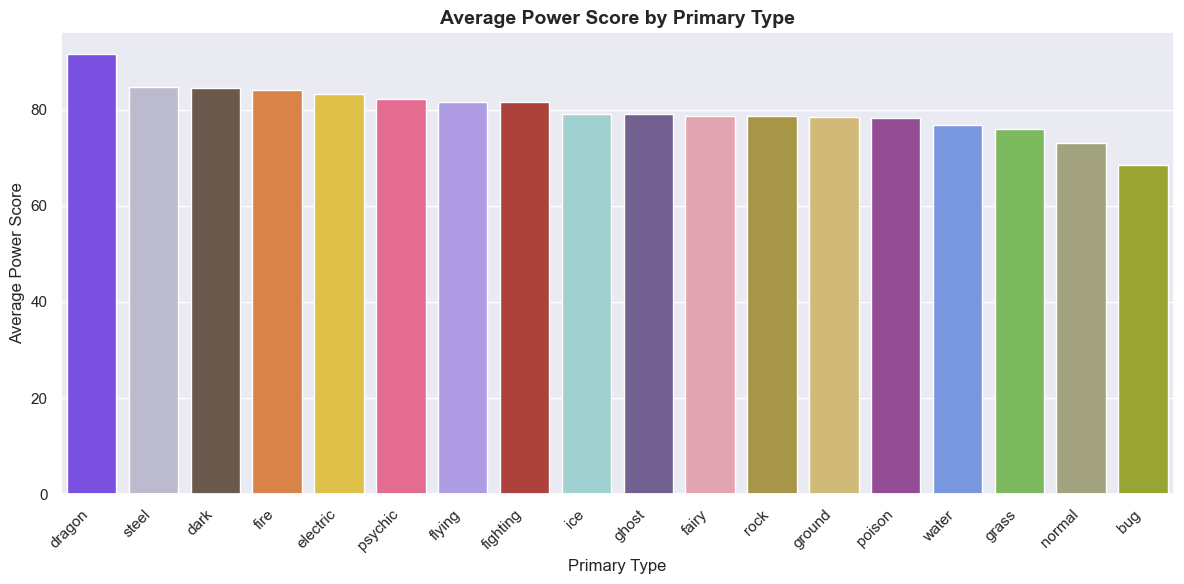

In [12]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=type_stats.sort_values('power_score', ascending=False).reset_index(),
    x='type1',
    y='power_score',
    hue='type1',
    legend=False,
    palette=type_colors
)
plt.title('Average Power Score by Primary Type', fontsize=14, fontweight='bold')
plt.xlabel('Primary Type')
plt.ylabel('Average Power Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

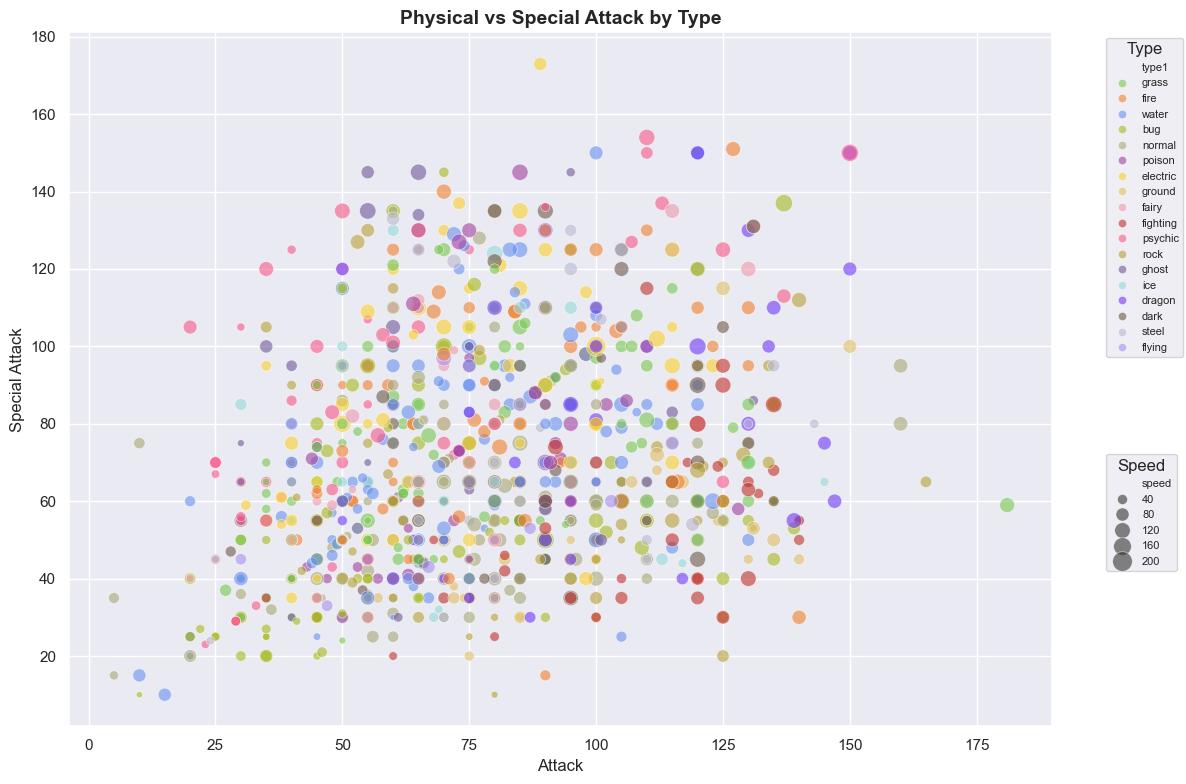

In [13]:
fig, ax = plt.subplots(figsize=(12, 8))

scatter = sns.scatterplot(
    data=df,
    x='attack',
    y='sp_attack',
    hue='type1',
    alpha=0.6,
    size='speed',
    sizes=(20, 200),
    palette=type_colors,
    ax=ax
)

handles, labels = ax.get_legend_handles_labels()

size_start = labels.index('speed') 

type_legend = ax.legend(
    handles[:size_start],
    labels[:size_start],
    title='Type',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=8
)

ax.add_artist(type_legend)

ax.legend(
    handles[size_start:],
    labels[size_start:],
    title='Speed',
    bbox_to_anchor=(1.05, 0.4),
    loc='upper left',
    fontsize=8
)

plt.title('Physical vs Special Attack by Type', fontsize=14, fontweight='bold')
plt.xlabel('Attack')
plt.ylabel('Special Attack')
plt.tight_layout()
plt.show()

In [14]:
stat_colors = {
    'hp': '#FF5959',
    'attack': '#F5AC78',
    'defense': '#FAE078',
    'sp_attack': '#9DB7F5',
    'sp_defense': '#A7DB8D',
    'speed': '#FA92B2'
}

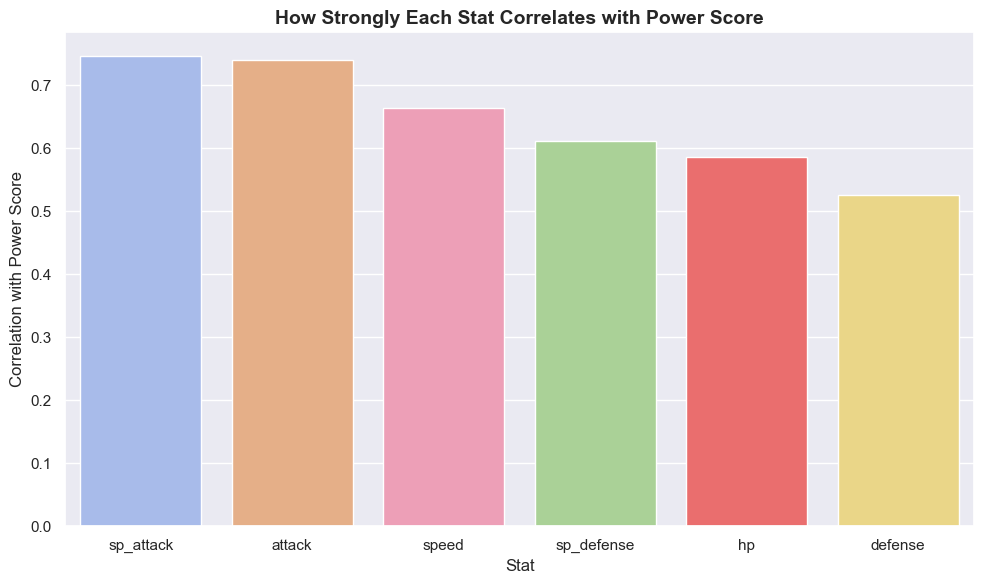

In [15]:
correlations = df[['hp', 'attack', 'defense', 'sp_attack', 
                    'sp_defense', 'speed']].corrwith(df['power_score']).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=correlations.index,
    y=correlations.values,
    hue=correlations.index,
    legend=False,
    palette=stat_colors
)
plt.title('How Strongly Each Stat Correlates with Power Score', fontsize=14, fontweight='bold')
plt.xlabel('Stat')
plt.ylabel('Correlation with Power Score')
plt.tight_layout()
plt.show()

In [16]:
def classify(row):
    if row['is_mythical']:
        return 'Mythical'
    elif row['is_legendary']:
        return 'Legendary'
    else:
        return 'Regular'

df['classification'] = df.apply(classify, axis=1)
df['classification'].value_counts()

classification
Regular      931
Legendary     71
Mythical      23
Name: count, dtype: int64

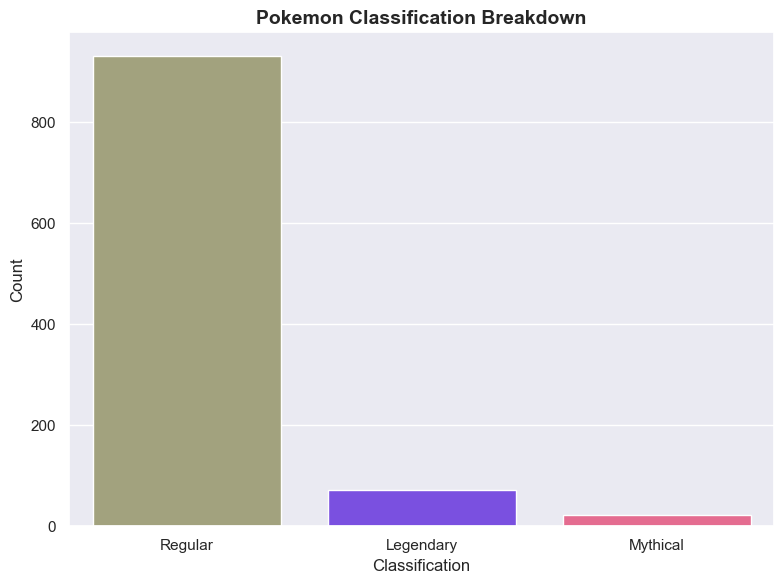

In [17]:
counts = df['classification'].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(
    x=counts.index,
    y=counts.values,
    hue=counts.index,
    legend=False,
    palette={'Regular': '#A8A878', 'Legendary': '#7038F8', 'Mythical': '#F85888'}
)
plt.title('Pokemon Classification Breakdown', fontsize=14, fontweight='bold')
plt.xlabel('Classification')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

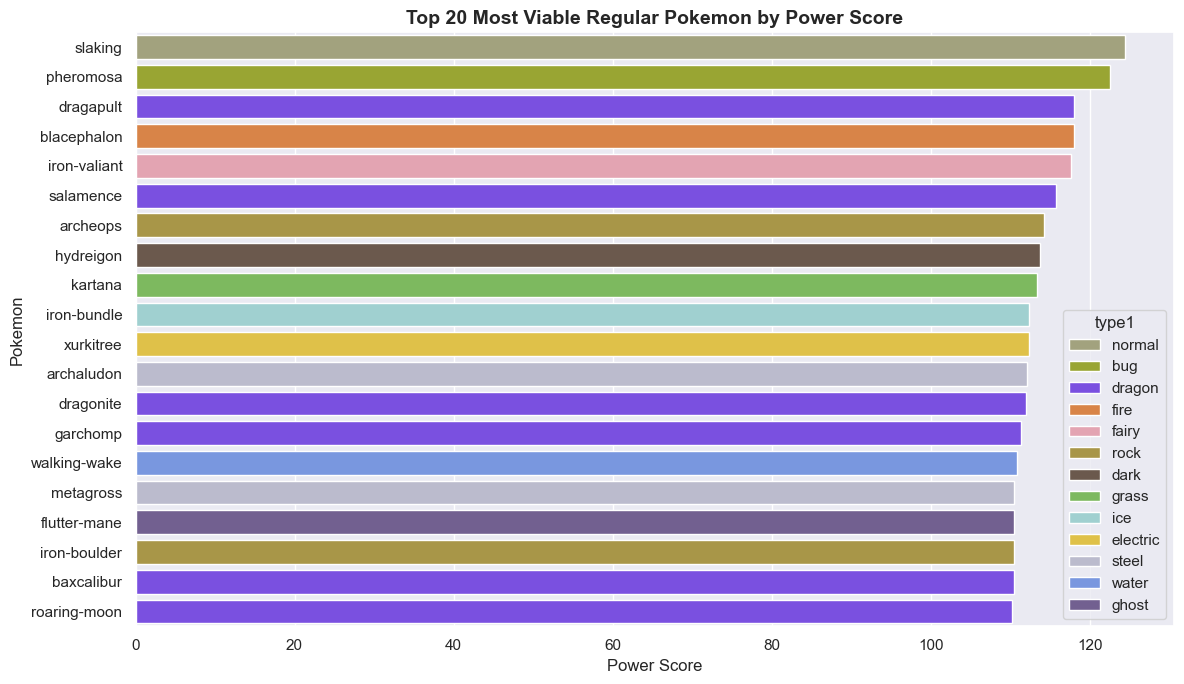

In [18]:
regular_only = df[
    (df['is_legendary'] == False) & 
    (df['is_mythical'] == False)
].copy()

top20 = regular_only.sort_values('power_score', ascending=False).head(20)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top20,
    x='power_score',
    y='name',
    hue='type1',
    dodge=False,
    legend=True,
    palette=type_colors
)
plt.title('Top 20 Most Viable Regular Pokemon by Power Score', fontsize=14, fontweight='bold')
plt.xlabel('Power Score')
plt.ylabel('Pokemon')
plt.tight_layout()
plt.show()